# Paleo SST patterns with land ice, and Pliocene ELAI

Separate experimental version of `paleo_patterns.ipynb`. This version normalizes each LGM reconstruction before averaging and uses 60°S–60°N open-ocean weights for every SST pattern. Ice is an illustrative geography overlay, not a simulated response to the SST patterns.

# Paleo SST anomaly patterns

Equal-weight mean LGM reconstruction, plioDA **KM5c / PlioVar**, and the prescribed **LongRunMIP 2×CO₂** pattern. Anomalies are relative to each suite's LGMR late-Holocene baseline (called `Preindustrial` in the source notebooks).

Sources in `/glade/u/home/vcooper/projects/plio_pattern/analysis` (cell indices below are zero-based):

- `hydro_analysis.ipynb`, cell 24 (`lgm['CAM4']`), and `hydro_monthly.ipynb`: the four LGM patterns **LGMR, Annan, Amrhein, Tierney**. The loading definitions and individual maps were located; a pre-existing four-pattern averaging cell was not located. Here each of the four **anomalies is normalized separately**, then the four normalized patterns are averaged with equal weight.
- `plio_analysis.ipynb`, cell 24: `plioDA['CAM5']['PlioVar']`, `LongRunMIP`, and their matching baseline. Cell 46 explicitly identifies PlioVar as “KM5c Only” and uses the custom `BuOr` map. We use the CAM5 prescribed SST for both warm patterns, not the atmospheric temperature response.
- `single_forcing_clean.ipynb`: full-LGM iCESM1.2 case `b.e12.B1850C5.f19_g16.i21ka.03`, climatology years 801–900, for `LANDFRAC`.
- `hydro_analysis.ipynb`, cell 6: `domain.lnd.fv0.9_1.25_gx1v6plioenh.190801_latlon.nc` for Pliocene land fraction.
- `bayecs/cmip6_hist_ens.ipynb` and `figures/ecs/fig_sst_pattern.png`: Pacific-centered Robinson projection, serif typography, gray land, thin black coastlines, dashed graticules, and a shared discrete colorbar.

Normalization: local ΔSST divided by the **absolute cell-area-weighted ocean mean ΔSST within 60°S–60°N**, using modern land fraction <0.0001. Each LGM reconstruction has its own denominator; their four normalized fields are then averaged with equal weight. The plotted LGM pattern is therefore `mean_i(ΔSST_i / abs(mean_ocean_60(ΔSST_i)))`, not a normalized average of dimensional anomalies. Pliocene and LongRunMIP are each normalized by their own 60°S–60°N ocean mean. Cooling remains negative. Paleo coastline and lake masks affect display, not the normalization domain. This supersedes the initial global-ocean, average-before-normalization method in the original notebook.

Paleo shorelines are the **0.5 land-fraction contour at the model grid resolution**. The prescribed SST fields include infilled values over modern land; changing the displayed coastlines does not reconstruct additional SST information in newly exposed ocean areas. No modern coastlines or modern land polygons are drawn on the paleo panels.

Executed and checked using the `aris` conda environment. The notebook retains the source-path table, normalization diagnostics, and rendered figure.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from IPython.display import display

DATA_ROOT = Path('/glade/u/home/vcooper/projects/plio_pattern/data')
ARCHIVE_ROOT = Path('/glade/derecho/scratch/vcooper/archive')
BAYECS_ROOT = Path('/glade/u/home/vcooper/work/hist_sst/bayecs')
FIGURE_DIR = BAYECS_ROOT / 'figures' / 'ecs'
SAVE_FIGURES = True
VABS = 2.0
NLEVELS = 20
COAST_THRESHOLD = 0.5

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['TeX Gyre Termes', 'Times New Roman', 'Times', 'STIXGeneral'],
    'mathtext.fontset': 'stix', 'font.size': 9,
    'axes.titlesize': 10, 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})
ICE_FRACTION_MIN = 0.5
ICE_MIN_ELEVATION_M = 500.0

LAND_GRAY = '0.58'
LAKE_FRACTION_MIN = 0.5
LAKE_COLOR = '#eef3f5'

NORMALIZATION_LAT_MAX = 60.0
ICE_COLOR_VMIN = 500.0
ICE_COLOR_VMAX = 3000.0
ICE_CMAP_FRACTION = 0.40


## Load the prescribed SST climatologies

Use the same equal-month average over the final 25 simulation years as `loadtseries_case30yr` in the source notebooks. CAM monthly timestamps denote the following month's start; the source date slice selects 300 months, January year 6 through December year 30. Coordinate alignment is checked explicitly before subtracting or stacking fields.

In [2]:
LGM_CASES = {
    'LGMR': 'f.e1221.F_2000.f19_f19.LGMRlgm.003',
    'Annan': 'f.e1221.F_2000.f19_f19.annan-seasbyamr.002.1',
    'Amrhein': 'f.e1221.F_2000.f19_f19.amrhein.002.1',
    'Tierney': 'f.e1221.F_2000.f19_f19.lgmDA.002',
}
LGM_BASELINE = 'f.e1221.F_2000.f19_f19.LGMRholo.003'
PLIOVAR_CASE = 'f.e215.F2000climoCAM5.f19_f19.tplio_vFpliovar'
LONGRUNMIP_CASE = 'f.e215.F2000climoCAM5.f19_f19.longrunmip.002'
WARM_BASELINE = 'f.e215.F2000climoCAM5.f19_f19.LGMRholo.003'
source_records = []


def load_sst(case):
    path = (ARCHIVE_ROOT / case / 'atm/proc/tseries/month_1'
            / f'{case}.cam.h0.SST.000101-003012.nc')
    with xr.open_dataset(path) as ds:
        monthly = ds['SST'].sel(time=slice('0006-01-02', '0031-01-01'))
        assert monthly.sizes['time'] == 300, f'Unexpected month count: {case}'
        field = monthly.mean('time', skipna=False).load().transpose('lat', 'lon')
    field.attrs.update(source=str(path), case=case, units='K',
                       averaging='Equal-month mean, simulation years 6–30')
    source_records.append({'case': case, 'variable': 'SST', 'source': str(path)})
    return field


def anomaly(field, baseline):
    field, baseline = xr.align(field, baseline, join='exact')
    result = field - baseline
    result.attrs.update(units='K', source=field.attrs['source'],
                        baseline_source=baseline.attrs['source'])
    return result


lgm_baseline = load_sst(LGM_BASELINE)
warm_baseline = load_sst(WARM_BASELINE)
lgm_members = xr.concat(
    [anomaly(load_sst(case), lgm_baseline) for case in LGM_CASES.values()],
    dim=pd.Index(LGM_CASES, name='reconstruction'), join='exact',
).rename('lgm_sst_anomaly_members')
# Raw ensemble mean is retained only for dimensional diagnostics.
# The map averages separately normalized members in the normalization cell below.
lgm_mean = lgm_members.mean('reconstruction', skipna=False)
plio_anomaly = anomaly(load_sst(PLIOVAR_CASE), warm_baseline)
longrun_anomaly = anomaly(load_sst(LONGRUNMIP_CASE), warm_baseline)
sst_anomaly = xr.concat(
    [lgm_mean, plio_anomaly, longrun_anomaly],
    dim=pd.Index(['LGM', 'Pliocene', 'LongRunMIP'], name='pattern'), join='exact',
).rename('sst_anomaly')
sst_anomaly.attrs = {'units': 'K', 'long_name': 'Prescribed SST anomaly relative to late Holocene'}
assert lgm_members.sizes['reconstruction'] == 4
assert np.isfinite(sst_anomaly).all().item()
display(pd.DataFrame(source_records))

,case,variable,source
0,f.e1221.F_2000.f19_f19.LGMRholo.003,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
1,f.e215.F2000climoCAM5.f19_f19.LGMRholo.003,SST,/glade/derecho/scratch/vcooper/archive/f.e215....
2,f.e1221.F_2000.f19_f19.LGMRlgm.003,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
3,f.e1221.F_2000.f19_f19.annan-seasbyamr.002.1,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
4,f.e1221.F_2000.f19_f19.amrhein.002.1,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
5,f.e1221.F_2000.f19_f19.lgmDA.002,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
6,f.e215.F2000climoCAM5.f19_f19.tplio_vFpliovar,SST,/glade/derecho/scratch/vcooper/archive/f.e215....
7,f.e215.F2000climoCAM5.f19_f19.longrunmip.002,SST,/glade/derecho/scratch/vcooper/archive/f.e215....


## Land fractions and normalization

Keep the native Pliocene 0.9° × 1.25° grid for its coastline; SSTs remain on their native 1.9° × 2.5° grid. The LGM land fraction comes from the full-LGM climatology, not a modern-geography SST-only experiment.

In [3]:
MODERN_DOMAIN = DATA_ROOT / 'ref/domain.lnd.fv1.9x2.5_gx1v6.090206.nc'
PLIO_DOMAIN = DATA_ROOT / 'mdvorak_cesm1.2/domain.lnd.fv0.9_1.25_gx1v6plioenh.190801_latlon.nc'
LGM_LANDFRAC_FILE = Path(
    '/glade/campaign/cesm/community/palwg/LastGlacialMaximum/iCESM1.2/'
    'b.e12.B1850C5.f19_g16.i21ka.03/climo/'
    'b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.0801-0900.climo.nc'
)
with xr.open_dataset(MODERN_DOMAIN) as ds:
    # Validate the domain grid before assigning 1D coordinates.
    np.testing.assert_allclose(ds.xc.isel(nj=0), sst_anomaly.lon)
    np.testing.assert_allclose(ds.yc.isel(ni=0), sst_anomaly.lat, atol=1e-6)
    modern = ds[['area', 'frac']].drop_vars(['xc', 'yc']).rename(
        {'nj': 'lat', 'ni': 'lon'}).assign_coords(
        lat=sst_anomaly.lat, lon=sst_anomaly.lon).load()
with xr.open_dataset(PLIO_DOMAIN) as ds:
    plio_landfrac = ds['frac'].load().transpose('lat', 'lon')
with xr.open_dataset(LGM_LANDFRAC_FILE) as ds:
    # Geography should be invariant across the twelve climatological months.
    assert float(ds.LANDFRAC.std('time').max()) < 1e-6
    lgm_landfrac = ds.LANDFRAC.isel(time=0, drop=True).load().transpose('lat', 'lon')
for landfrac in (modern.frac, lgm_landfrac, plio_landfrac):
    assert np.isfinite(landfrac).all().item()
    assert float(landfrac.min()) >= 0 and float(landfrac.max()) <= 1

normalization_mask = (modern.frac < 0.0001) & (abs(modern.lat) <= NORMALIZATION_LAT_MAX)
open_ocean_area = modern.area.where(normalization_mask, 0)
weights = open_ocean_area / open_ocean_area.sum()
np.testing.assert_allclose(weights.sum(), 1)
assert float(weights.where(abs(weights.lat) > NORMALIZATION_LAT_MAX, 0).sum()) == 0
member_means = lgm_members.weighted(weights).mean(('lat', 'lon'))
assert (member_means < -1e-6).all().item()
lgm_normalized_members = (lgm_members / abs(member_means)).rename('lgm_normalized_members')
lgm_normalized_mean = lgm_normalized_members.mean('reconstruction', skipna=False)
# The warm patterns each have a single denominator.
plio_mean = plio_anomaly.weighted(weights).mean(('lat', 'lon'))
longrun_mean = longrun_anomaly.weighted(weights).mean(('lat', 'lon'))
assert float(plio_mean) > 0 and float(longrun_mean) > 0
normalized_sst = xr.concat(
    [lgm_normalized_mean, plio_anomaly / abs(plio_mean), longrun_anomaly / abs(longrun_mean)],
    dim=pd.Index(['LGM', 'Pliocene', 'LongRunMIP'], name='pattern'), join='exact',
).rename('normalized_sst_anomaly')
normalized_sst.attrs = {
    'units': 'K K-1',
    'normalization': 'absolute cell-area-weighted ocean mean within 60S–60N; modern land fraction <0.0001',
    'lgm_averaging': 'equal mean of four separately normalized reconstruction anomalies',
}
np.testing.assert_allclose(lgm_normalized_members.weighted(weights).mean(('lat', 'lon')), -np.ones(4), atol=1e-12)
np.testing.assert_allclose(normalized_sst.weighted(weights).mean(('lat', 'lon')), [-1, 1, 1], atol=1e-12)
xr.testing.assert_allclose(normalized_sst.sel(pattern='LGM', drop=True), lgm_normalized_members.mean('reconstruction', skipna=False))
mean_sst_anomaly = sst_anomaly.weighted(weights).mean(('lat', 'lon'))
diagnostics = pd.DataFrame({
    'raw_ocean_mean_60S_60N_K': mean_sst_anomaly.values,
    'single_normalization_denominator_K': [np.nan, abs(float(plio_mean)), abs(float(longrun_mean))],
    'normalized_min': normalized_sst.min(('lat', 'lon')).values,
    'normalized_max': normalized_sst.max(('lat', 'lon')).values,
}, index=sst_anomaly.pattern.values)
print('LGM: normalize each reconstruction first, then average the four normalized patterns.')
print('Normalization domain for every pattern: area-weighted modern open ocean within ±60° latitude.')
print('LGM has four denominators, so its single-denominator diagnostic is NaN.')
display(diagnostics)
display(member_means.to_series().rename('LGM member ocean-mean anomaly, 60S–60N [K]'))


LGM: normalize each reconstruction first, then average the four normalized patterns.
Normalization domain for every pattern: area-weighted modern open ocean within ±60° latitude.
LGM has four denominators, so its single-denominator diagnostic is NaN.


,raw_ocean_mean_60S_60N_K,single_normalization_denominator_K,normalized_min,normalized_max
LGM,-2.975096,NaN,-8.495360,4.385097
Pliocene,2.893458,2.893458,0.228376,5.576345
LongRunMIP,2.404740,2.404740,0.012957,8.229927


reconstruction
LGMR      -4.026218
Annan     -2.276225
Amrhein   -2.296337
Tierney   -3.301604
Name: LGM member ocean-mean anomaly, 60S–60N [K], dtype: float64

## Land-ice overlay

LGM and modern ice: ICE-6G Peltier 21 ka and 0 ka `sftgif` (percent ice fraction) and `orog` (surface altitude in metres). Pliocene ice: CESM2 PlioMIP2 `PCT_GLACIER` and `PHIS / 9.80616` on the matching grid. The LongRunMIP panel uses modern ice-sheet geography, not an equilibrium ice-sheet projection.

Elevation contours, shaded with the whitest 40% of Matplotlib `bone`, show cells with **ice fraction > 50% and surface elevation ≥ 500 m**. Both thresholds can be changed above. This is a display filter: lower-elevation glaciers are deliberately excluded. Ice is also restricted to the displayed land mask, using cyclic nearest-neighbor sampling where grids differ. No ice thickness is used as altitude.

All three panels share an ice color scale from 500–3000 m; elevations above 3000 m use white. The display mask still requires surface elevation ≥500 m; color limits are independent of this mask. A separate elevation colorbar identifies this scale.

SST display limits are ±2 K/K; land is gray 0.58. The non-vegetation figure has **no lake masking or lake fill**. Only the vegetation version masks lake-dominated cells (PCT_LAKE ≥50%) and displays them pale blue. Lake fractions come from the surface dataset, not the domain file.

In [4]:
TOPO_ROOT = DATA_ROOT / 'topo_paleo/cesm21_pliomip2'
ICE6G_ROOT = Path('/glade/derecho/scratch/vcooper/p2c2/transfer/ice6g')
PLIO_SURFACE = TOPO_ROOT / 'surfdata_0.9x1.25_hist_16pfts_nourb_CMIP6_pliomip2_c190830.90latlon.prescribed.nc'
PLIO_TOPO = TOPO_ROOT / 'topo_plioenh_remap_0.9x1.25_cesm2_simple.fix2.nc'


def surface_field(ds, name):
    return ds[name].rename({'lsmlat': 'lat', 'lsmlon': 'lon'}).assign_coords(
        lat=ds.LATIXY[:, 0].values, lon=ds.LONGXY[0, :].values).load()


def land_on_grid(land, target):
    # Periodic longitude extension avoids a missing strip at the dateline.
    land = land.assign_coords(lon=land.lon % 360).sortby('lon')
    extended = xr.concat([land.assign_coords(lon=land.lon - 360), land,
                          land.assign_coords(lon=land.lon + 360)], dim='lon')
    return extended.interp(lat=target.lat, lon=target.lon % 360, method='nearest').assign_coords(lat=target.lat, lon=target.lon)


ice_fraction, ice_elevation = {}, {}
for key, age in [('LGM', 21), ('LongRunMIP', 0)]:
    with xr.open_dataset(ICE6G_ROOT / f'I6_C.VM5a_1deg.{age}.nc') as ds:
        ice_fraction[key] = (ds.sftgif / 100).load()
        ice_elevation[key] = ds.orog.load()
with xr.open_dataset(PLIO_SURFACE) as ds:
    ice_fraction['Pliocene'] = surface_field(ds, 'PCT_GLACIER') / 100
    plio_lakefrac = surface_field(ds, 'PCT_LAKE') / 100
with xr.open_dataset(PLIO_TOPO) as ds:
    ice_elevation['Pliocene'] = (ds.PHIS / 9.80616).load()

# These files store the same grid with different floating-point precision.
np.testing.assert_allclose(ice_fraction['Pliocene'].lat, ice_elevation['Pliocene'].lat, atol=1e-5)
np.testing.assert_allclose(ice_fraction['Pliocene'].lon, ice_elevation['Pliocene'].lon, atol=1e-5)
ice_elevation['Pliocene'] = ice_elevation['Pliocene'].assign_coords(
    lat=ice_fraction['Pliocene'].lat, lon=ice_fraction['Pliocene'].lon)

land_for_ice = {'LGM': lgm_landfrac, 'Pliocene': plio_landfrac,
                'LongRunMIP': modern.frac}
ice_masks = {}
for key in ['LGM', 'Pliocene', 'LongRunMIP']:
    frac, elevation = xr.align(ice_fraction[key], ice_elevation[key], join='exact')
    land = land_on_grid(land_for_ice[key], frac)
    mask = ((frac > ICE_FRACTION_MIN) & (elevation >= ICE_MIN_ELEVATION_M)
            & (land >= COAST_THRESHOLD))
    ice_masks[key] = mask.astype(float)
    assert mask.any().item(), f'No ice selected for {key}'
    assert not (mask & (elevation < ICE_MIN_ELEVATION_M)).any().item()
    print(f'{key}: {int(mask.sum())} native-grid cells selected as land ice')

plio_lakes = ((plio_lakefrac >= LAKE_FRACTION_MIN)
              & (land_on_grid(plio_landfrac, plio_lakefrac) >= COAST_THRESHOLD))
plio_sst_lakes = land_on_grid(plio_lakes.astype(float), normalized_sst.sel(pattern='Pliocene')) >= 0.5
# A plotting copy leaves normalization and source anomalies unchanged.
normalized_sst_for_plot = normalized_sst.copy()
normalized_sst_for_plot.loc[dict(pattern='Pliocene')] = normalized_sst.sel(pattern='Pliocene').where(~plio_sst_lakes)
print(f'Pliocene CESM2 lake mask: {int(plio_lakes.sum())} native cells')


LGM: 10834 native-grid cells selected as land ice
Pliocene: 3873 native-grid cells selected as land ice
LongRunMIP: 6195 native-grid cells selected as land ice
Pliocene CESM2 lake mask: 64 native cells


Saved /glade/work/vcooper/hist_sst/bayecs/figures/ecs/fig_paleo_patterns_ice.png


Saved /glade/work/vcooper/hist_sst/bayecs/figures/ecs/fig_paleo_patterns_ice.pdf


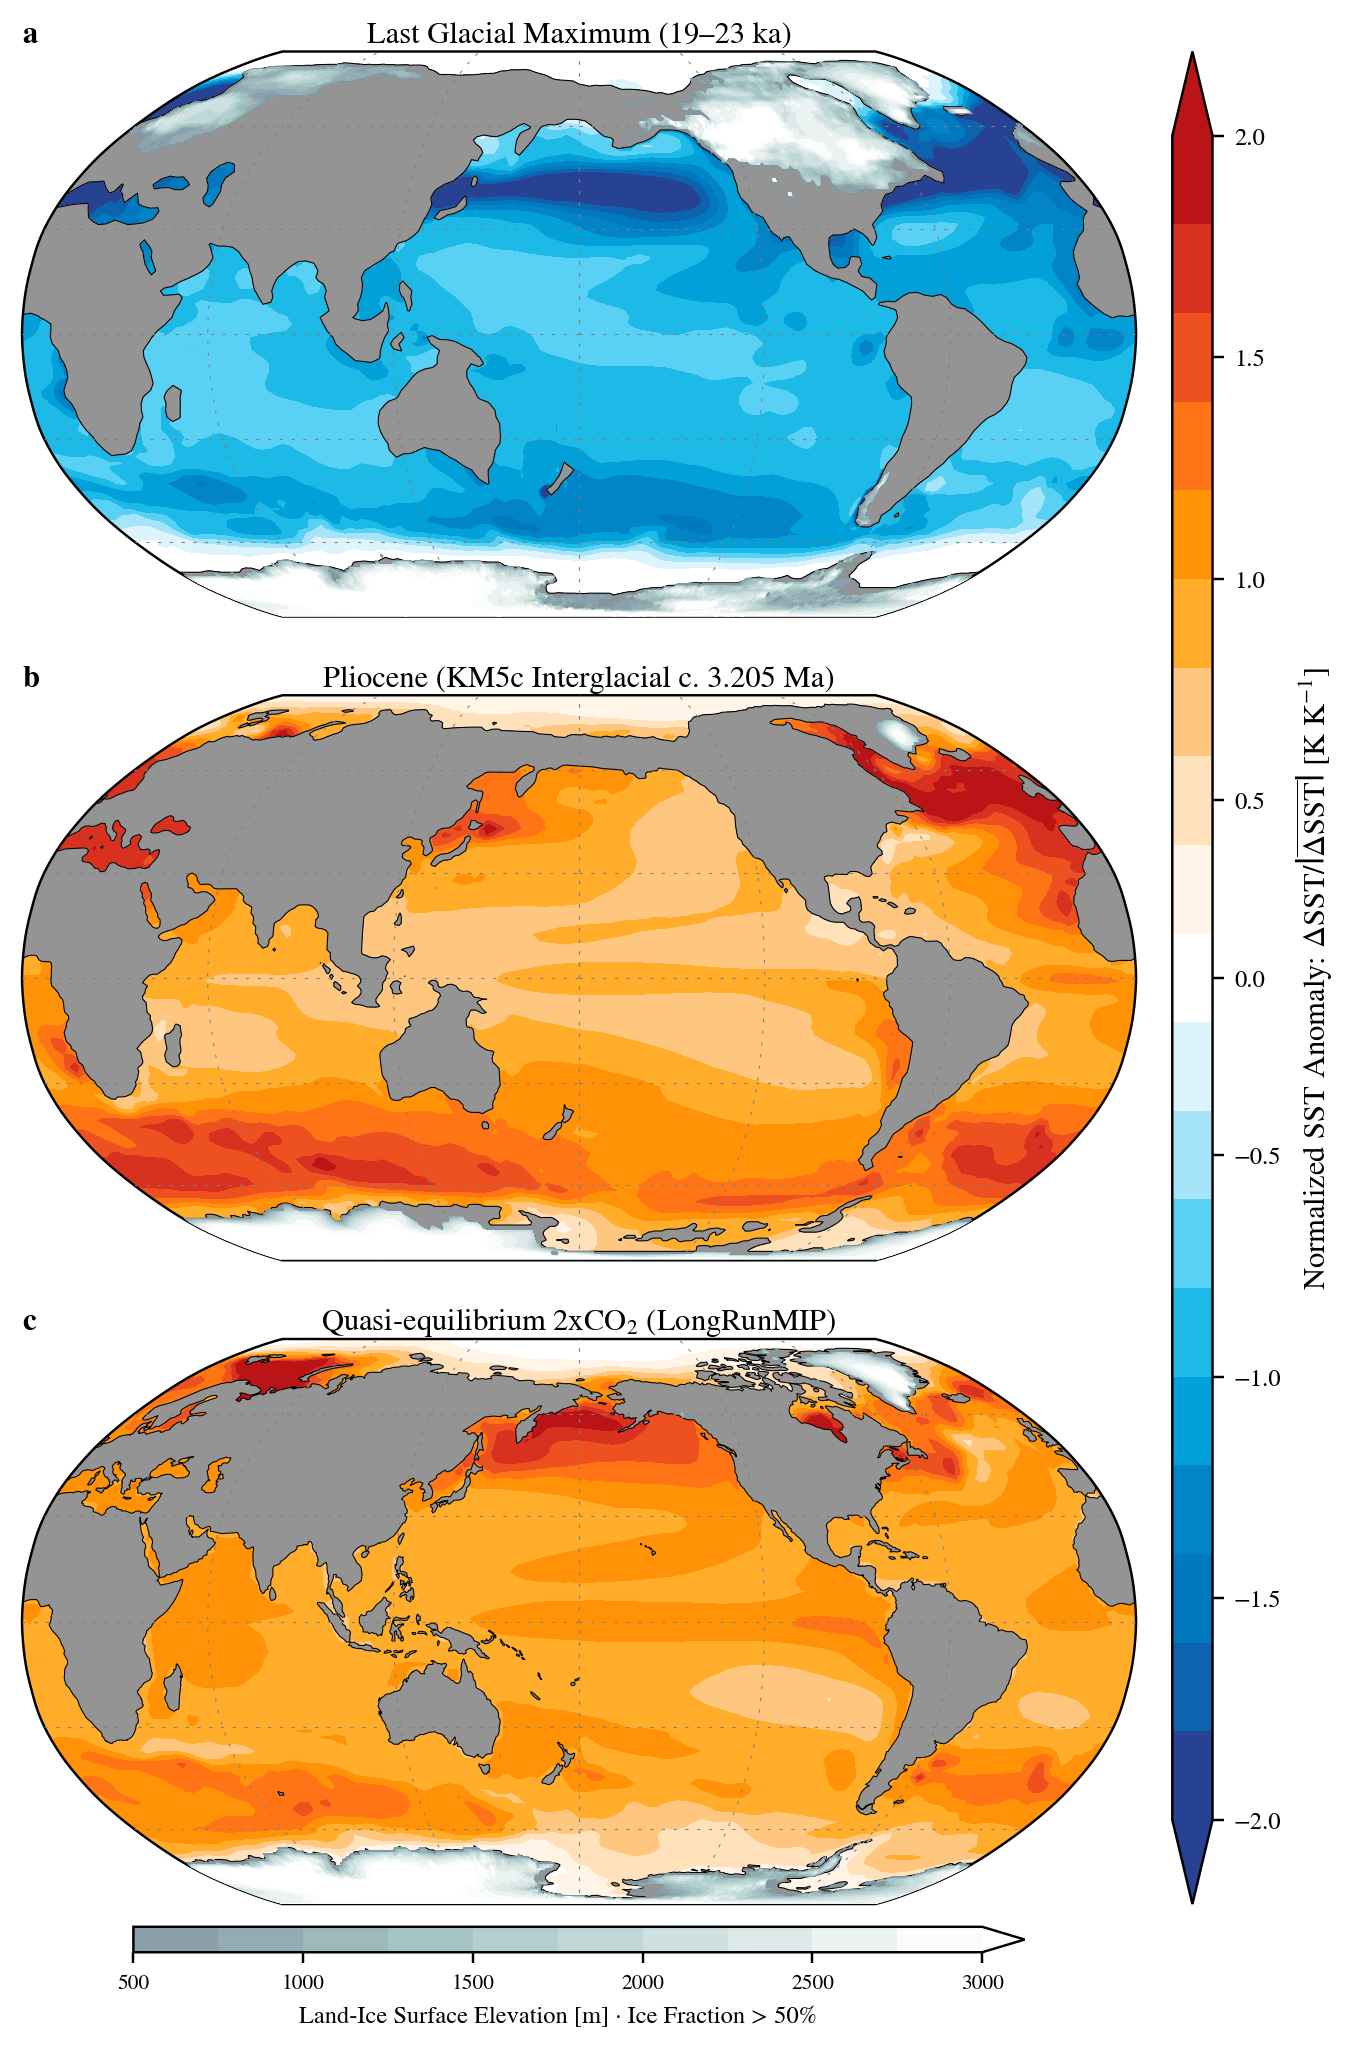

In [5]:
buor_colors = np.array([
    (39, 66, 147), (0, 115, 187), (1, 133, 199), (1, 174, 224),
    (88, 209, 244), (205, 238, 252), (255, 255, 255),
    (255, 238, 217), (255, 198, 127), (255, 161, 0),
    (255, 117, 21), (230, 63, 37), (187, 20, 22),
]) / 255.0
BuOr = LinearSegmentedColormap.from_list('BuOr', buor_colors)
assert NLEVELS % 2 == 0
levels = np.delete(np.linspace(-VABS, VABS, NLEVELS + 1), NLEVELS // 2)
cmap = BuOr.resampled(NLEVELS - 1)


def cyclic(field):
    field = field.transpose('lat', 'lon')
    values, longitude = add_cyclic_point(field.values, coord=field.lon.values, axis=-1)
    return longitude, field.lat.values, values


def fix_white_contours(contours):
    # Matplotlib >=3.8 makes the contour set itself a collection.
    if hasattr(contours, 'set_edgecolor'):
        contours.set_edgecolor('face')
        contours.set_linewidth(0.01)
    else:
        for collection in contours.collections:
            collection.set_edgecolor('face')
            collection.set_linewidth(0.01)


# Restrict the palette to the whitest 40%, preserving darker-low/whiter-high ordering.
ice_cmap = LinearSegmentedColormap.from_list(
    'bone_whitest_40percent', mpl.colormaps['bone'](np.linspace(1 - ICE_CMAP_FRACTION, 1.0, 256)))
ice_levels = np.arange(ICE_COLOR_VMIN, ICE_COLOR_VMAX + 1, 250.0)

def plot_paleo_ice(vegetation=None, stem='fig_paleo_patterns_ice', vegetation_lakes=None):
    panels = [
        ('a', 'Last Glacial Maximum (19–23 ka)', 'LGM', lgm_landfrac),
        ('b', 'Pliocene (KM5c Interglacial c. 3.205 Ma)', 'Pliocene', plio_landfrac),
        ('c', r'Quasi-equilibrium 2xCO$_2$ (LongRunMIP)', 'LongRunMIP', None),
    ]
    fig = plt.figure(figsize=(6.2, 9.7 if vegetation is not None else 9.2), dpi=220, layout='constrained')
    grid = fig.add_gridspec(5 if vegetation is not None else 4, 2, width_ratios=(1, 0.035),
                             height_ratios=(1, 1, 1, 0.045, 0.045) if vegetation is not None else (1, 1, 1, 0.045),
                             hspace=0.045, wspace=0.025)
    axes = [fig.add_subplot(grid[row, 0], projection=ccrs.Robinson(central_longitude=-180))
            for row in range(3)]
    cax = fig.add_subplot(grid[:3, 1])
    ice_cax = fig.add_subplot(grid[3, 0])
    if vegetation is not None:
        veg_cax = fig.add_subplot(grid[4, 0])
    for axis, (letter, title, key, landfrac) in zip(axes, panels):
        sst_for_panel = normalized_sst_for_plot if vegetation is not None else normalized_sst
        longitude, latitude, values = cyclic(sst_for_panel.sel(pattern=key))
        contours = axis.contourf(
            longitude, latitude, values, levels=levels, cmap=cmap, extend='both',
            antialiased=False, transform=ccrs.PlateCarree(), zorder=1,
        )
        fix_white_contours(contours)
        if landfrac is None:
            axis.add_feature(cfeature.LAND.with_scale('110m'), facecolor=LAND_GRAY,
                             edgecolor='none', zorder=2)
            axis.coastlines(resolution='110m', color='k', linewidth=0.35, zorder=3)
        else:
            coast_lon, coast_lat, coast_values = cyclic(landfrac)
            axis.contourf(
                coast_lon, coast_lat, coast_values,
                levels=[COAST_THRESHOLD, 1.01], colors=[LAND_GRAY],
                transform=ccrs.PlateCarree(), antialiased=False, zorder=2,
            )
            axis.contour(
                coast_lon, coast_lat, coast_values, levels=[COAST_THRESHOLD],
                colors='k', linewidths=0.35, transform=ccrs.PlateCarree(), zorder=3,
            )
        if key == 'Pliocene':
            if vegetation is not None:
                vegetation_on_land = vegetation.where(
                    (land_on_grid(plio_landfrac, vegetation) >= COAST_THRESHOLD)
                    & (land_on_grid(plio_lakes.astype(float), vegetation) < 0.5))
                veg_lon, veg_lat, veg_values = cyclic(vegetation_on_land)
                veg_contours = axis.contourf(
                    veg_lon, veg_lat, veg_values, levels=np.arange(0, 6.01, 0.5),
                    cmap=mpl.colormaps['YlGn'], extend='max', corner_mask=True,
                    transform=ccrs.PlateCarree(), zorder=2.4, antialiased=False)
                fix_white_contours(veg_contours)
            if vegetation is not None:
                display_lakes = plio_lakes
                if vegetation_lakes is not None:
                    display_lakes = display_lakes | (land_on_grid(vegetation_lakes.astype(float), plio_lakes) >= 0.5)
                lake_lon, lake_lat, lake_values = cyclic(display_lakes.astype(float))
                axis.contourf(lake_lon, lake_lat, lake_values, levels=[0.5, 1.5],
                              colors=[LAKE_COLOR], transform=ccrs.PlateCarree(), zorder=2.8)
        ice_lon, ice_lat, ice_values = cyclic(ice_masks[key])
        # A pale base preserves the original mask boundary at partially masked cells.
        axis.contourf(ice_lon, ice_lat, ice_values, levels=[0.5, 1.5],
                      colors=[ice_cmap(0.0)], transform=ccrs.PlateCarree(), zorder=3.15,
                      antialiased=False)
        elevation = ice_elevation[key].where(ice_masks[key].astype(bool))
        elevation_lon, elevation_lat, elevation_values = cyclic(elevation)
        ice_contours = axis.contourf(
            elevation_lon, elevation_lat, elevation_values,
            levels=ice_levels, cmap=ice_cmap, extend='max',
            transform=ccrs.PlateCarree(), zorder=3.2, antialiased=False)
        fix_white_contours(ice_contours)
        axis.contour(ice_lon, ice_lat, ice_values, levels=[0.5], colors=['#7e969f'],
                     linewidths=0.25, transform=ccrs.PlateCarree(), zorder=3.3)
        axis.set_global()
        axis.gridlines(color='grey', linewidth=0.35, linestyle=(0, (3, 8)),
                       draw_labels=False, alpha=1, zorder=3)
        axis.set_title(letter, loc='left', fontweight='bold', pad=3)
        axis.set_title(title, fontsize=10, pad=3)
        axis.set_facecolor('none')
    colorbar = fig.colorbar(contours, cax=cax, orientation='vertical',
                            ticks=np.arange(-VABS, VABS + 0.01, 0.5))
    colorbar.set_label(r'Normalized SST Anomaly: $\Delta \mathrm{SST} / \left|\overline{\Delta \mathrm{SST}}\right|$ [K K$^{-1}$]')
    ice_bar = fig.colorbar(ice_contours, cax=ice_cax, orientation='horizontal',
                           ticks=[500, 1000, 1500, 2000, 2500, 3000])
    ice_bar.ax.tick_params(labelsize=7)
    ice_bar.set_label(
        f'Land-Ice Surface Elevation [m] · Ice Fraction > {ICE_FRACTION_MIN:.0%}', fontsize=8)
    if vegetation is not None:
        veg_bar = fig.colorbar(veg_contours, cax=veg_cax, orientation='horizontal', ticks=np.arange(0, 7))
        veg_bar.ax.tick_params(labelsize=7)
        veg_bar.set_label(r'Pliocene ELAI [m$^2$ m$^{-2}$] · 1150–1199', fontsize=8)
    fig.patch.set_alpha(0)
    fig.patch.set_facecolor('none')
    fig.canvas.draw()
    fig.set_layout_engine('none')
    # The original axes box includes the colorbar's maximum extension.
    # Center that full box on the maps, rather than centering the rectangular body.
    ice_box = ice_cax.get_position(original=True)
    map_box = axes[-1].get_position()
    map_center = 0.5 * (map_box.x0 + map_box.x1)
    ice_width = 0.8 * map_box.width
    ice_cax.set_position([map_center - ice_width / 2, ice_box.y0,
                          ice_width, ice_box.height])
    fig.canvas.draw()
    outline_box = ice_bar.outline.get_path().get_extents(
        ice_bar.outline.get_transform()).transformed(fig.transFigure.inverted())
    np.testing.assert_allclose(0.5 * (outline_box.x0 + outline_box.x1),
                               map_center, atol=1e-6)
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ('png', 'pdf'):
            output = FIGURE_DIR / f'{stem}.{extension}'
            fig.savefig(output, bbox_inches='tight', dpi=700, transparent=True)
            print(f'Saved {output}')
    plt.show()
    return fig

fig_ice_only = plot_paleo_ice()


## Pliocene exposed leaf area index: 1150–1199

ELAI comes from the fully coupled CESM1.2/CLM4 PlioMIP2 `modMed` simulation, not the KM5c SST-forced experiment. It is exposed one-sided leaf area per ground area (m²/m²), not percent cover. Use all 600 monthly means, weighted by the actual durations in `time_bounds`. This avoids assigning the next month's length to CAM/CLM end-of-month timestamps.

Use the output's own land fraction and its named CLM4 surface dataset for glacier cover. Ice-dominated land (≥50% glacier) is white and missing ice-free land is gray. Yellow denotes low ELAI and green high ELAI; this is vegetation density, not a biome/desert classification. The scale extends above 6 m²/m², and diagnostics below report the fraction of plotted land area above that limit. No extra land-fraction multiplication is applied to the local LAI values.

Lake-dominated cells (PCT_LAKE ≥50% from the named CLM4 surface file) are NaN in ELAI plots and shown in pale blue. PI uses its own surface-file lake fractions, and the difference excludes lake-dominated cells from either run.

In [6]:
ELAI_ROOT = Path('/glade/collections/cdg/data/PlioMIP2/b.e12.B1850.f09_g16.PIMP4-pliomip2.modMed/lnd/proc/tseries/month_1')
ELAI_FILE = ELAI_ROOT / 'b.e12.B1850.f09_g16.PIMP4-pliomip2.modMed.clm2.h0.ELAI.115001-119912.nc'
CLM4_SURFACE = DATA_ROOT / 'topo_paleo/icesm13_pliomip2/surfdata_0.9x1.25_plioenh_c190903.90latlon.nc'
with xr.open_dataset(ELAI_FILE) as ds:
    assert ds.sizes['time'] == 600
    bounds = ds.time_bounds.values
    assert (bounds[0, 0].year, bounds[0, 0].month, bounds[0, 0].day) == (1150, 1, 1)
    assert (bounds[-1, 1].year, bounds[-1, 1].month, bounds[-1, 1].day) == (1200, 1, 1)
    assert all(bounds[i, 1] == bounds[i + 1, 0] for i in range(len(bounds) - 1))
    duration_days = np.array([(end - start).total_seconds() / 86400 for start, end in bounds])
    assert np.isclose(duration_days.sum(), 50 * 365)
    duration = xr.DataArray(duration_days, dims='time', coords={'time': ds.time})
    elai_climatology = ds.ELAI.astype('float64').weighted(duration).mean('time').load()
    elai_valid_months = ds.ELAI.count('time').load()
    elai_landfrac = ds.landfrac.load()
    elai_area = ds.area.load()
    assert ds.attrs['Surface_dataset'] == CLM4_SURFACE.name
with xr.open_dataset(CLM4_SURFACE) as ds:
    elai_glacier = surface_field(ds, 'PCT_GLACIER') / 100
    elai_lakefrac = surface_field(ds, 'PCT_LAKE') / 100
# Coordinates differ only in float precision; validate before adopting output coordinates.
np.testing.assert_allclose(elai_glacier.lat, elai_climatology.lat, atol=1e-5)
np.testing.assert_allclose(elai_glacier.lon, elai_climatology.lon, atol=1e-5)
elai_glacier = elai_glacier.assign_coords(lat=elai_climatology.lat, lon=elai_climatology.lon)
np.testing.assert_allclose(elai_lakefrac.lat, elai_climatology.lat, atol=1e-5)
np.testing.assert_allclose(elai_lakefrac.lon, elai_climatology.lon, atol=1e-5)
elai_lakefrac = elai_lakefrac.assign_coords(lat=elai_climatology.lat, lon=elai_climatology.lon)
elai_land = elai_landfrac >= COAST_THRESHOLD
elai_lakes = elai_land & (elai_lakefrac >= LAKE_FRACTION_MIN)
elai_ice = elai_land & (elai_glacier >= ICE_FRACTION_MIN)
elai_plot = elai_climatology.where(elai_land & ~elai_ice & ~elai_lakes)
assert int(elai_valid_months.where(elai_plot.notnull()).min()) == 600
assert float(elai_plot.min()) >= 0
ELAI_VMAX = 6.0
plot_area = (elai_area * elai_landfrac).where(elai_plot.notnull(), 0)
saturated_fraction = float(plot_area.where(elai_plot > ELAI_VMAX, 0).sum() / plot_area.sum())
print('ELAI climatology: 600 months, 1150–1199, weighted by monthly duration')
print(f'Ice-free plotted ELAI range: {float(elai_plot.min()):.3f}–{float(elai_plot.max()):.3f} m²/m²')
print(f'Plotted land area with ELAI > {ELAI_VMAX:g}: {saturated_fraction:.2%}')
print(f'Ice-free land cells without ELAI: {int((elai_land & ~elai_ice & elai_climatology.isnull()).sum())}')
elai_climatology.attrs.update(units='m2 m-2', source=str(ELAI_FILE),
                              averaging='1150–1199; weighted by time-bound durations')

assert elai_plot.where(elai_lakes).isnull().all().item()
print(f'Pliocene CLM4 lake mask: {int(elai_lakes.sum())} cells')


ELAI climatology: 600 months, 1150–1199, weighted by monthly duration
Ice-free plotted ELAI range: 0.000–19.161 m²/m²
Plotted land area with ELAI > 6: 10.75%
Ice-free land cells without ELAI: 0
Pliocene CLM4 lake mask: 74 cells


Generated figure: fig_pliocene_elai_1150-1199_ylgn.png


Generated figure: fig_pliocene_elai_1150-1199_ylgn.pdf


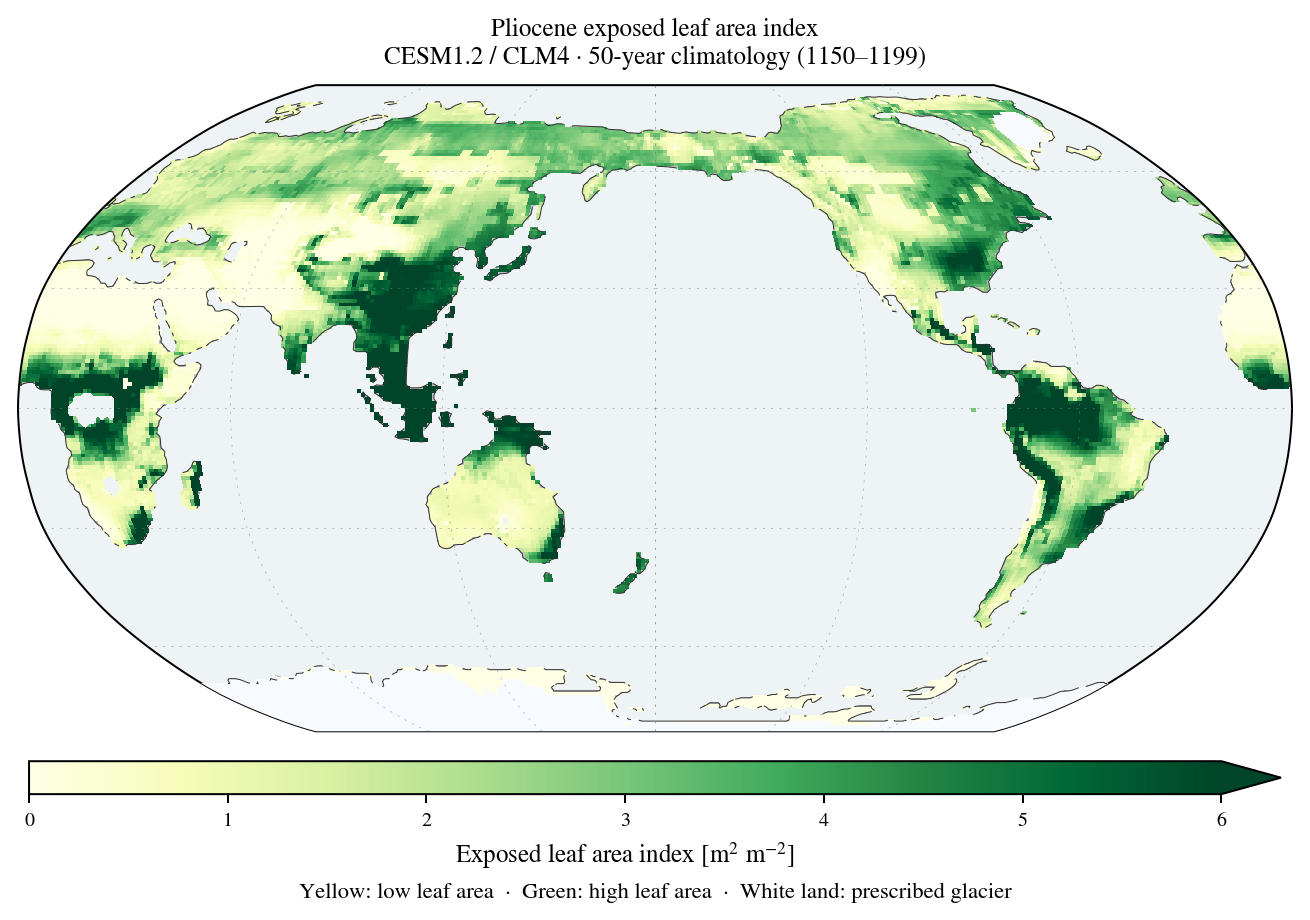

In [7]:
vegetation_cmap = mpl.colormaps['YlGn']
fig_elai = plt.figure(figsize=(9, 5.0), dpi=180, layout='constrained')
axis = fig_elai.add_subplot(111, projection=ccrs.Robinson(central_longitude=-180))
axis.set_facecolor('#eef3f5')
# Native cells preserve missing/coastal values rather than interpolating across oceans.
land_lon, land_lat, land_values = cyclic(elai_landfrac)
axis.contourf(land_lon, land_lat, land_values, levels=[COAST_THRESHOLD, 1.01],
              colors=['0.75'], transform=ccrs.PlateCarree(), zorder=1)
mesh = axis.pcolormesh(elai_plot.lon, elai_plot.lat, elai_plot,
                       cmap=vegetation_cmap, vmin=0, vmax=ELAI_VMAX,
                       shading='auto', rasterized=True,
                       transform=ccrs.PlateCarree(), zorder=2)
lake_lon, lake_lat, lake_values = cyclic(elai_lakes.astype(float))
axis.contourf(lake_lon, lake_lat, lake_values, levels=[0.5, 1.5], colors=[LAKE_COLOR],
              transform=ccrs.PlateCarree(), zorder=2.8)
ice_lon, ice_lat, ice_values = cyclic(elai_ice.astype(float))
axis.contourf(ice_lon, ice_lat, ice_values, levels=[0.5, 1.5], colors=['#f7fbff'],
              transform=ccrs.PlateCarree(), zorder=3)
axis.contour(land_lon, land_lat, land_values, levels=[COAST_THRESHOLD],
             colors=['0.2'], linewidths=0.4, transform=ccrs.PlateCarree(), zorder=4)
axis.set_global()
axis.gridlines(color='gray', linewidth=0.3, linestyle=(0, (3, 8)), alpha=0.6, zorder=5)
axis.set_title('Pliocene exposed leaf area index\nCESM1.2 / CLM4 · 50-year climatology (1150–1199)', pad=9)
cbar = fig_elai.colorbar(mesh, ax=axis, orientation='horizontal', shrink=0.78,
                         pad=0.04, aspect=38, extend='max', ticks=np.arange(0, ELAI_VMAX + 1, 1))
cbar.set_label(r'Exposed leaf area index [m$^2$ m$^{-2}$]')
fig_elai.supxlabel('Yellow: low leaf area  ·  Green: high leaf area  ·  White land: prescribed glacier', fontsize=9)
if SAVE_FIGURES:
    for extension in ('png', 'pdf'):
        output = FIGURE_DIR / f'fig_pliocene_elai_1150-1199_ylgn.{extension}'
        fig_elai.savefig(output, dpi=400, bbox_inches='tight', facecolor='white')
        print(f'Saved {output}')
plt.show()


## Preindustrial counterpart and Pliocene minus PI

Use the final 50 archived PI years, **757–806**, from `b.e12.B1850C5CN.f09_g16.preind`, with the same duration weighting as the **1150–1199** Pliocene climatology. Simulation-year labels need not match between these separate equilibrium experiments. Two files supply the PI window; the first contributes only years 757–758.

Each absolute map uses its own land fraction and prescribed glacier fraction. The difference is computed from the **unclipped** climatologies, then masked to valid land with glacier fraction <50% in **both** simulations. Gray indicates land excluded by this common-domain criterion. Thus changes in coastline and glacier extent are excluded from the vegetation comparison. Positive differences are green and negative differences are brown. Absolute ELAI uses 0–6 m²/m²; differences use a symmetric −3 to +3 m²/m² scale, with extensions for values outside the display ranges.

Lake-dominated cells in either run are also excluded from the difference and shown pale blue.

In [8]:
PI_CASE = 'b.e12.B1850C5CN.f09_g16.preind'
PI_ROOT = Path('/glade/collections/cdg/data/PlioMIP2') / PI_CASE / 'lnd/proc/tseries/month_1'
PI_FILES = [PI_ROOT / f'{PI_CASE}.clm2.h0.ELAI.{period}.nc'
            for period in ['070901-075812', '075901-080612']]
PI_SURFACE = Path('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/surfdata/surfdata_0.9x1.25_simyr1850_c110921.nc')
pi_parts, pi_bounds = [], []
for path in PI_FILES:
    with xr.open_dataset(path) as ds:
        bounds = ds.time_bounds.values
        keep = np.array([757 <= start.year <= 806 for start in bounds[:, 0]])
        pi_parts.append(ds.ELAI.isel(time=keep).astype('float64').load())
        pi_bounds.extend(bounds[keep])
        if path == PI_FILES[0]:
            pi_landfrac = ds.landfrac.load()
            pi_area = ds.area.load()
        else:
            xr.testing.assert_equal(pi_landfrac, ds.landfrac)
        assert ds.attrs['Surface_dataset'] == PI_SURFACE.name
pi_monthly = xr.concat(pi_parts, dim='time', join='exact')
assert pi_monthly.sizes['time'] == 600
assert (pi_bounds[0][0].year, pi_bounds[0][0].month) == (757, 1)
assert (pi_bounds[-1][1].year, pi_bounds[-1][1].month) == (807, 1)
assert all(pi_bounds[i][1] == pi_bounds[i + 1][0] for i in range(599))
pi_days = np.array([(end - start).total_seconds() / 86400 for start, end in pi_bounds])
assert np.isclose(pi_days.sum(), 50 * 365)
pi_duration = xr.DataArray(pi_days, dims='time', coords={'time': pi_monthly.time})
pi_elai = pi_monthly.weighted(pi_duration).mean('time')
pi_valid_months = pi_monthly.count('time')
with xr.open_dataset(PI_SURFACE) as ds:
    pi_glacier = surface_field(ds, 'PCT_GLACIER') / 100
    pi_lakefrac = surface_field(ds, 'PCT_LAKE') / 100
np.testing.assert_allclose(pi_glacier.lat, pi_elai.lat, atol=1e-5)
np.testing.assert_allclose(pi_glacier.lon, pi_elai.lon, atol=1e-5)
pi_glacier = pi_glacier.assign_coords(lat=pi_elai.lat, lon=pi_elai.lon)
np.testing.assert_allclose(pi_lakefrac.lat, pi_elai.lat, atol=1e-5)
np.testing.assert_allclose(pi_lakefrac.lon, pi_elai.lon, atol=1e-5)
pi_lakefrac = pi_lakefrac.assign_coords(lat=pi_elai.lat, lon=pi_elai.lon)
pi_land = pi_landfrac >= COAST_THRESHOLD
pi_lakes = pi_land & (pi_lakefrac >= LAKE_FRACTION_MIN)
pi_ice = pi_land & (pi_glacier >= ICE_FRACTION_MIN)
pi_plot = pi_elai.where(pi_land & ~pi_ice & ~pi_lakes)
assert int(pi_valid_months.where(pi_plot.notnull()).min()) == 600
assert float(pi_plot.min()) >= 0
plio_aligned, pi_aligned = xr.align(elai_climatology, pi_elai, join='exact')
common_land = elai_land & pi_land
common_icefree = common_land & ~elai_ice & ~pi_ice & ~elai_lakes & ~pi_lakes
elai_difference = (plio_aligned - pi_aligned).where(common_icefree).rename('ELAI_plio_minus_pi')
elai_difference.attrs.update(units='m2 m-2',
    long_name='Pliocene 1150–1199 minus PI 757–806 exposed leaf area index',
    mask='land fraction >= 0.5, glacier fraction < 0.5, lake fraction < 0.5 in both runs')
np.testing.assert_allclose((elai_difference + pi_aligned).where(common_icefree),
                           plio_aligned.where(common_icefree), atol=1e-12, equal_nan=True)
assert int((common_icefree & elai_difference.isnull()).sum()) == 0
ELAI_DIFF_VABS = 3.0
pi_plot_area = (pi_area * pi_landfrac).where(pi_plot.notnull(), 0)
pi_saturation = float(pi_plot_area.where(pi_plot > ELAI_VMAX, 0).sum() / pi_plot_area.sum())
diff_area = (elai_area * np.minimum(elai_landfrac, pi_landfrac)).where(elai_difference.notnull(), 0)
diff_saturation = float(diff_area.where(abs(elai_difference) > ELAI_DIFF_VABS, 0).sum() / diff_area.sum())
print(f'PI: 600 months, 757–806; ELAI range {float(pi_plot.min()):.3f}–{float(pi_plot.max()):.3f} m²/m²')
print(f'PI plotted land area above {ELAI_VMAX:g}: {pi_saturation:.2%}')
print(f'Pliocene minus PI range: {float(elai_difference.min()):.3f}–{float(elai_difference.max()):.3f} m²/m²')
print(f'Difference plotted area outside ±{ELAI_DIFF_VABS:g}: {diff_saturation:.2%}')
del pi_monthly, pi_parts

assert elai_difference.where(elai_lakes | pi_lakes).isnull().all().item()


PI: 600 months, 757–806; ELAI range 0.000–13.296 m²/m²
PI plotted land area above 6: 10.03%
Pliocene minus PI range: -9.123–10.585 m²/m²
Difference plotted area outside ±3: 5.80%


Generated figure: fig_elai_plio_pi_comparison_ylgn.png


Generated figure: fig_elai_plio_pi_comparison_ylgn.pdf


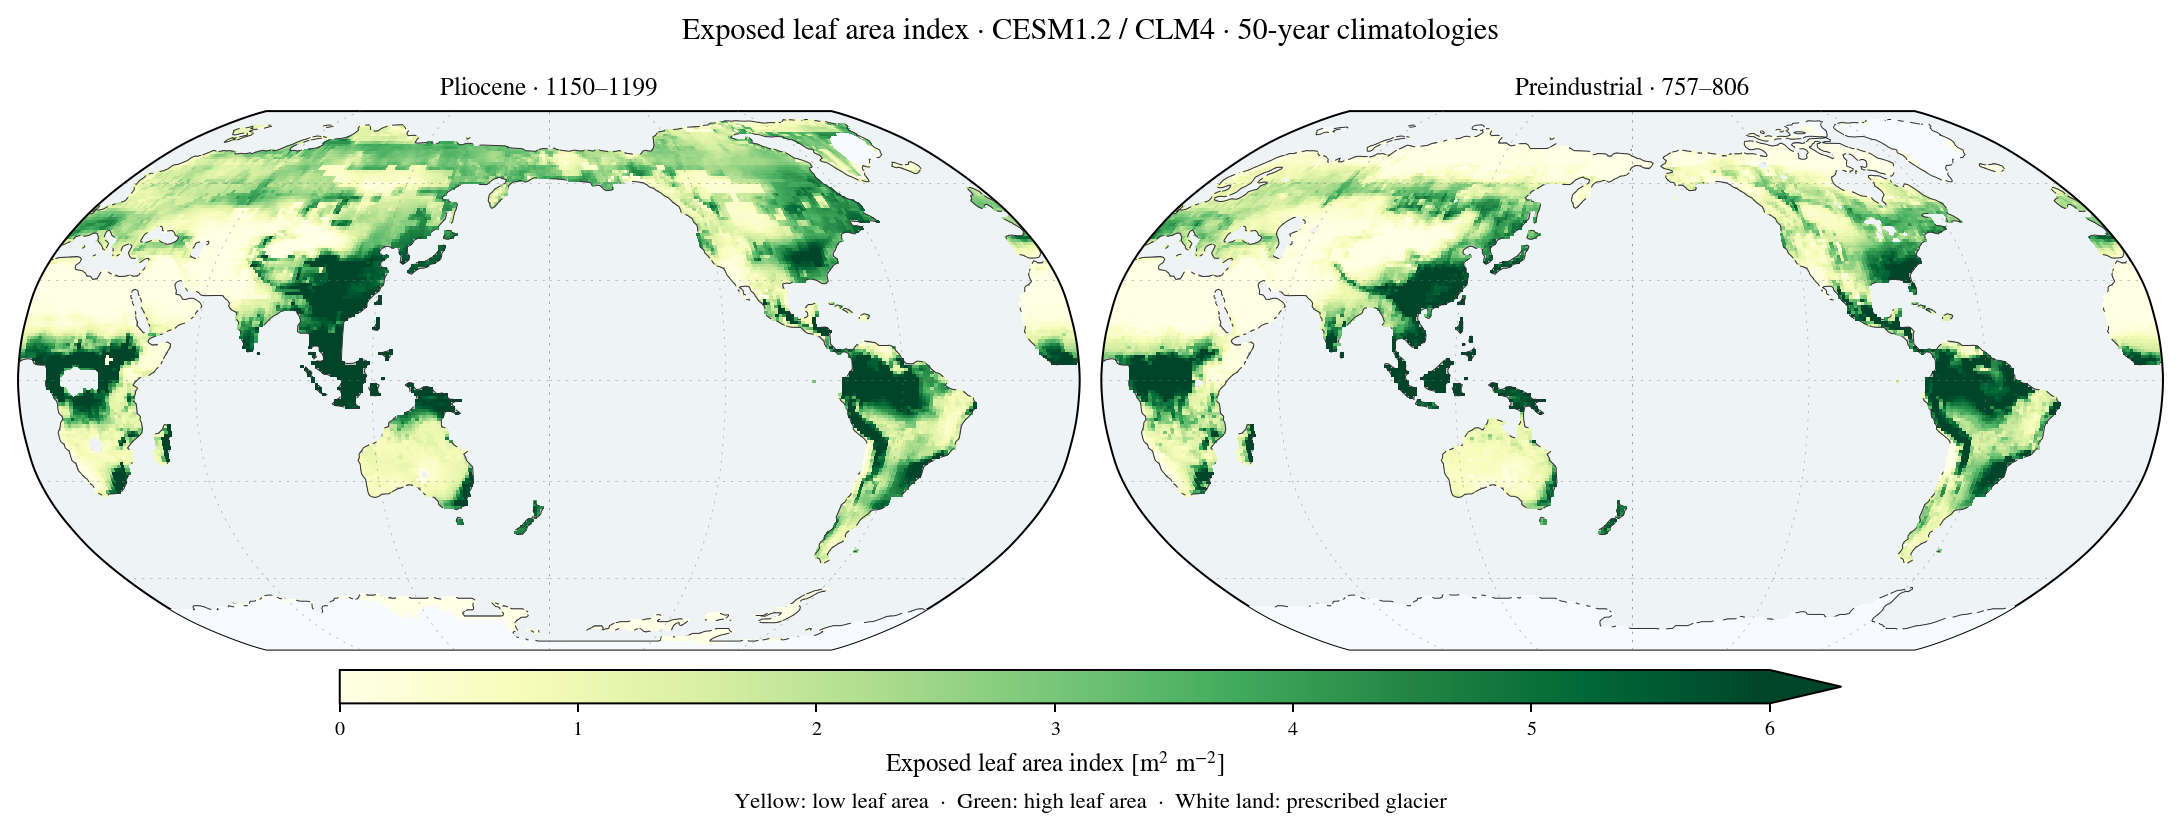

Generated figure: fig_elai_plio_minus_pi_range3.png


Generated figure: fig_elai_plio_minus_pi_range3.pdf


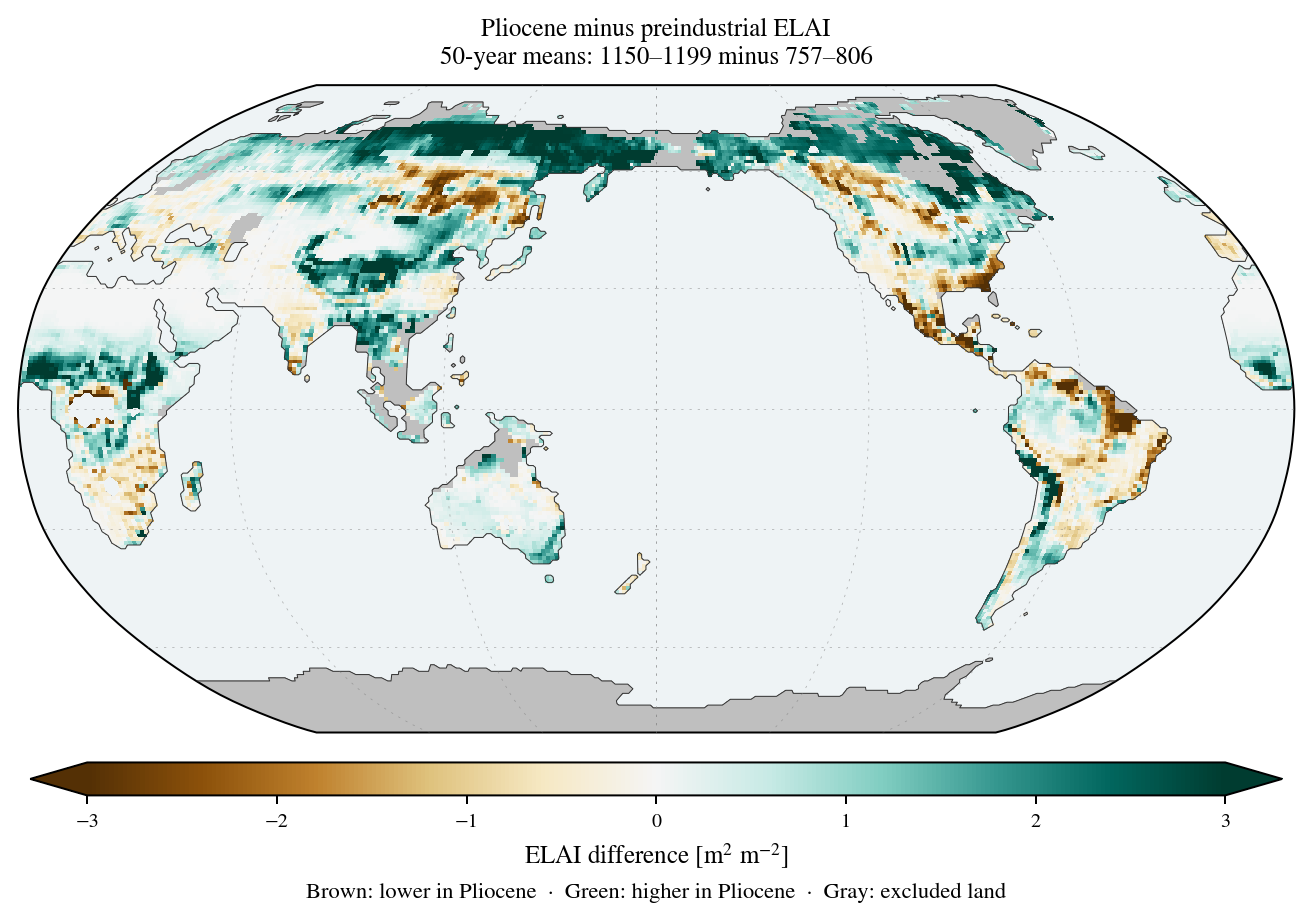

In [9]:
def elai_map(axis, field, landfrac, ice=None, cmap=vegetation_cmap, vmin=0, vmax=ELAI_VMAX, lakes=None):
    axis.set_facecolor('#eef3f5')
    lon, lat, land = cyclic(landfrac)
    axis.contourf(lon, lat, land, levels=[COAST_THRESHOLD, 1.01], colors=['0.75'],
                  transform=ccrs.PlateCarree(), zorder=1)
    mesh = axis.pcolormesh(field.lon, field.lat, field, cmap=cmap, vmin=vmin, vmax=vmax,
                           shading='auto', rasterized=True,
                           transform=ccrs.PlateCarree(), zorder=2)
    if lakes is not None:
        llon, llat, lvalues = cyclic(lakes.astype(float))
        axis.contourf(llon, llat, lvalues, levels=[0.5, 1.5], colors=[LAKE_COLOR],
                      transform=ccrs.PlateCarree(), zorder=2.8)
    if ice is not None:
        ilon, ilat, ivals = cyclic(ice.astype(float))
        axis.contourf(ilon, ilat, ivals, levels=[0.5, 1.5], colors=['#f7fbff'],
                      transform=ccrs.PlateCarree(), zorder=3)
    axis.contour(lon, lat, land, levels=[COAST_THRESHOLD], colors=['0.2'],
                 linewidths=0.4, transform=ccrs.PlateCarree(), zorder=4)
    axis.set_global()
    axis.gridlines(color='gray', linewidth=0.3, linestyle=(0, (3, 8)), alpha=0.6, zorder=5)
    return mesh


def save_elai_figure(figure, stem):
    if SAVE_FIGURES:
        for extension in ('png', 'pdf'):
            output = FIGURE_DIR / f'{stem}.{extension}'
            figure.savefig(output, dpi=400, bbox_inches='tight', facecolor='white')
            print(f'Saved {output}')


fig_compare, axes_compare = plt.subplots(1, 2, figsize=(12, 4.5), dpi=180,
    subplot_kw={'projection': ccrs.Robinson(central_longitude=-180)}, layout='constrained')
for axis, field, landfrac, ice, lakes, title in [
    (axes_compare[0], elai_plot, elai_landfrac, elai_ice, elai_lakes, 'Pliocene · 1150–1199'),
    (axes_compare[1], pi_plot, pi_landfrac, pi_ice, pi_lakes, 'Preindustrial · 757–806'),
]:
    mesh = elai_map(axis, field, landfrac, ice, lakes=lakes)
    axis.set_title(title, pad=7)
fig_compare.suptitle('Exposed leaf area index · CESM1.2 / CLM4 · 50-year climatologies', fontsize=12)
bar = fig_compare.colorbar(mesh, ax=list(axes_compare), orientation='horizontal',
                           shrink=0.7, pad=0.03, aspect=45, extend='max', ticks=np.arange(0, 7))
bar.set_label(r'Exposed leaf area index [m$^2$ m$^{-2}$]')
fig_compare.supxlabel('Yellow: low leaf area  ·  Green: high leaf area  ·  White land: prescribed glacier', fontsize=9)
save_elai_figure(fig_compare, 'fig_elai_plio_pi_comparison_ylgn')
plt.show()

fig_difference = plt.figure(figsize=(9, 5), dpi=180, layout='constrained')
axis = fig_difference.add_subplot(111, projection=ccrs.Robinson(central_longitude=-180))
# The union land mask shows land excluded from subtraction in gray.
union_landfrac = xr.where(elai_land | pi_land, 1.0, 0.0)
mesh = elai_map(axis, elai_difference, union_landfrac, cmap=mpl.colormaps['BrBG'],
                vmin=-ELAI_DIFF_VABS, vmax=ELAI_DIFF_VABS, lakes=elai_lakes | pi_lakes)
axis.set_title('Pliocene minus preindustrial ELAI\n50-year means: 1150–1199 minus 757–806', pad=9)
bar = fig_difference.colorbar(mesh, ax=axis, orientation='horizontal', shrink=0.78,
                              pad=0.04, aspect=38, extend='both', ticks=np.arange(-ELAI_DIFF_VABS, ELAI_DIFF_VABS + 0.1, 1))
bar.set_label(r'ELAI difference [m$^2$ m$^{-2}$]')
fig_difference.supxlabel('Brown: lower in Pliocene  ·  Green: higher in Pliocene  ·  Gray: excluded land', fontsize=9)
save_elai_figure(fig_difference, 'fig_elai_plio_minus_pi_range3')
plt.show()


## Separate SST + ice + vegetation experiment

The Pliocene panel combines the KM5c/PlioVar SST reconstruction with the **1150–1199 PlioMIP2 ELAI climatology** as `contourf` (YlGn, 0–6 m²/m², 0.5 intervals), and the elevation-shaded ice. Vegetation is contextual output from a different coupled experiment, not a response to the KM5c SST forcing. Lake-dominated cells are excluded. LGM and LongRunMIP retain gray land.


Saved figures/ecs/fig_paleo_patterns_ice_vegetation.png


Saved figures/ecs/fig_paleo_patterns_ice_vegetation.pdf


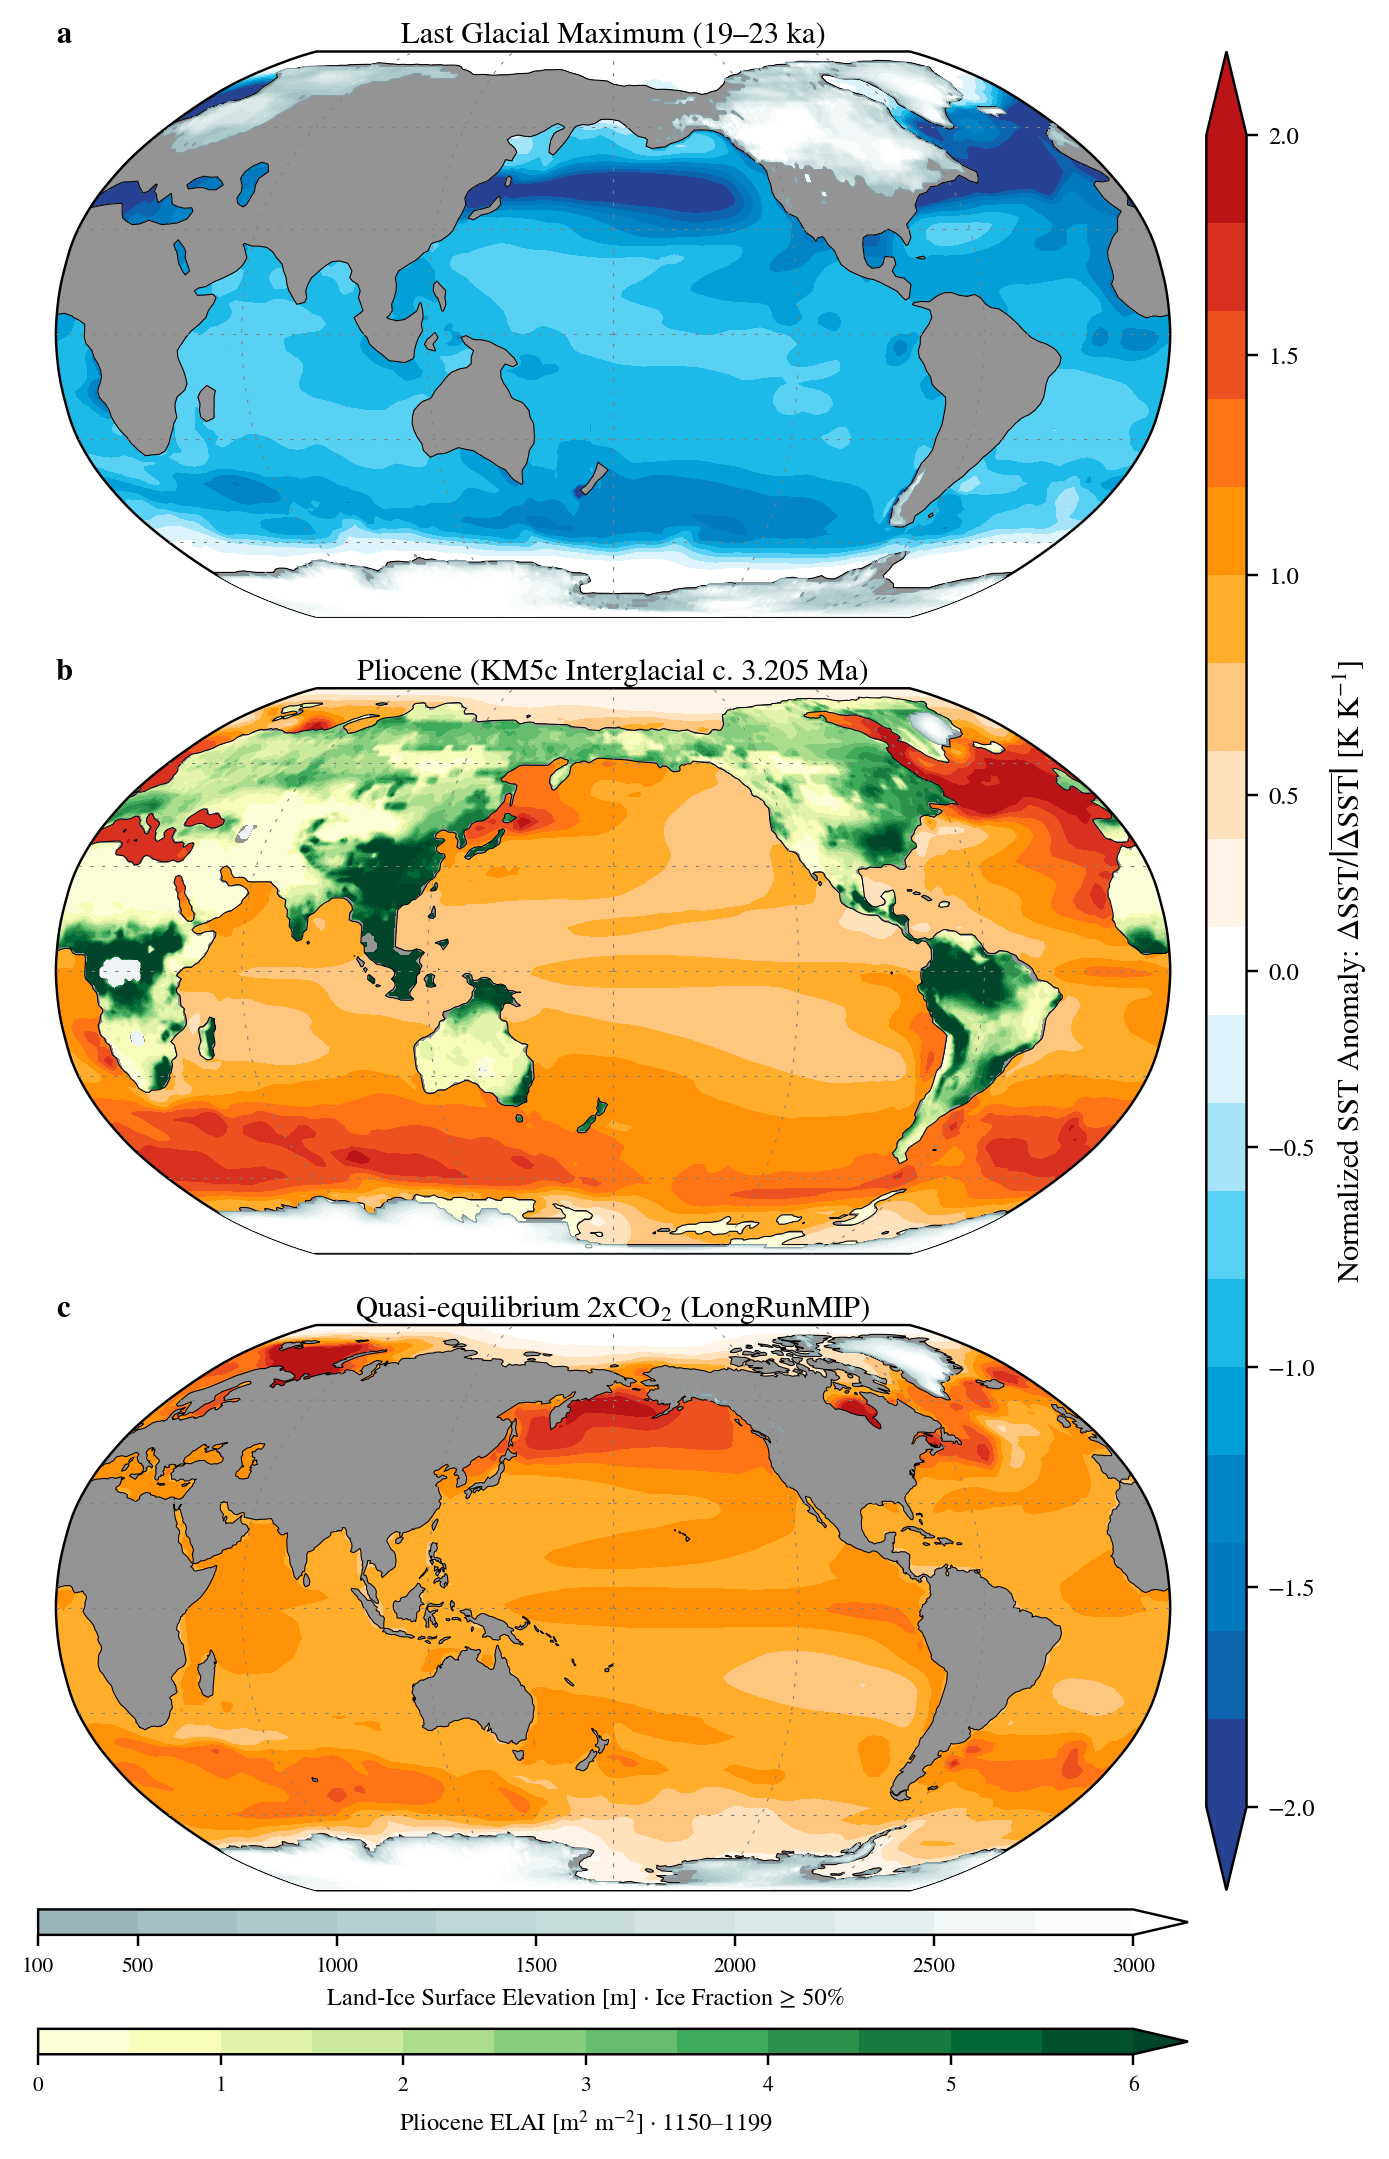

In [7]:
fig_vegetation = plot_paleo_ice(vegetation=elai_plot, vegetation_lakes=elai_lakes, stem='fig_paleo_patterns_ice_vegetation')

### Publication export: non-vegetation figure

Follow `community_ecs.ipynb`: PDF with embedded TrueType fonts, a tight bounding box, and explicit save DPI (600 here). Preserve the map layout and transparent background. Only the non-vegetation figure is exported.

In [6]:
save_publication_figure = True
publication_save_dpi = 600
if save_publication_figure:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    publication_path = FIGURE_DIR / 'fig_paleo_patterns_ice.pdf'
    with mpl.rc_context({'pdf.fonttype': 42, 'ps.fonttype': 42,
                         'savefig.dpi': publication_save_dpi}):
        previous_dpi = fig_ice_only.dpi
        try:
            fig_ice_only.set_dpi(publication_save_dpi)
            fig_ice_only.savefig(publication_path, bbox_inches='tight',
                                dpi=publication_save_dpi, transparent=True)
        finally:
            fig_ice_only.set_dpi(previous_dpi)
    print(f'Saved publication PDF: {publication_path} ({publication_save_dpi} dpi)')

Saved publication PDF: /glade/work/vcooper/hist_sst/bayecs/figures/ecs/fig_paleo_patterns_ice.pdf (600 dpi)
